In [1]:
import pandas as pd

df = pd.read_excel(r"C:\Users\daksh\Desktop\Excel for Data Analysis\Nifty 50 stock prices dataset.csv.xlsx")
# Quick look at data
print(df.head())


                 date     open     high      low    close  volume
0 2015-02-02 09:15:00  1000.85  1008.65  1000.85  1005.05    8664
1 2015-02-02 09:20:00  1005.00  1008.25  1003.55  1006.75    1824
2 2015-02-02 09:25:00  1006.75  1007.85  1003.95  1006.40     831
3 2015-02-02 09:30:00  1006.40  1006.40  1004.05  1004.90    1805
4 2015-02-02 09:35:00  1004.90  1004.90  1003.20  1003.20     746


In [4]:
# Convert Date column to datetime
df['date'] = pd.to_datetime(df['date'])

# Sort by date (ascending)
df = df.sort_values(by='date')

# Reset index
df = df.reset_index(drop=True)

In [5]:
# Check missing values
print(df.isnull().sum())

# Simple approach: drop missing rows
df = df.dropna()

date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64


In [10]:
#Daily Returns 
df['Return'] = df['close'].pct_change()

In [13]:
#Moving Averages
df['MA_7'] = df['close'].rolling(window=7).mean()
df['MA_30'] = df['close'].rolling(window=30).mean()

In [14]:
#Volatility 
df['Volatility'] = df['Return'].rolling(window=7).std()

In [15]:
#Create target variable 
df['Target'] = (df['close'].shift(-1) > df['close']).astype(int)

In [16]:
#Cleanup after feature engineering 
df = df.dropna()

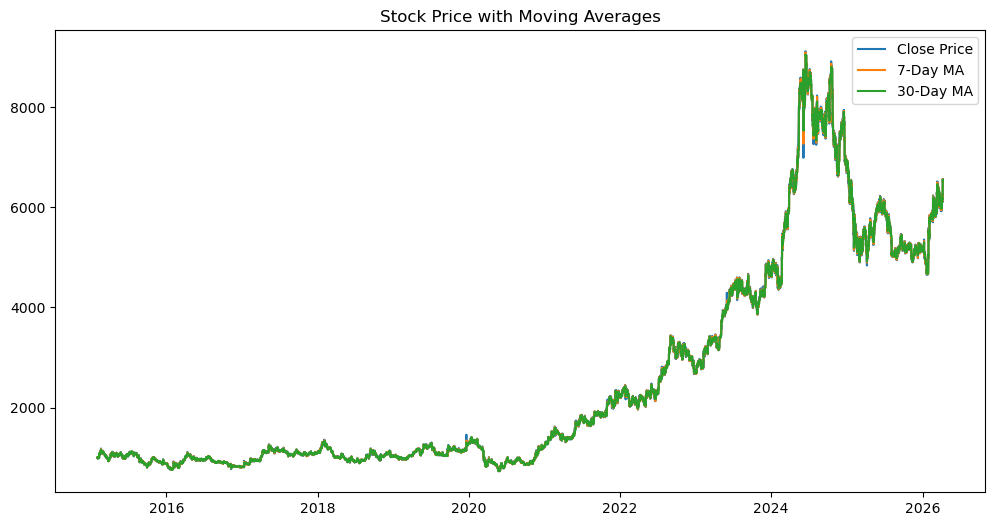

In [18]:
#PLotting Stock Price + Moving Averages
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df['date'], df['close'], label='Close Price')
plt.plot(df['date'], df['MA_7'], label='7-Day MA')
plt.plot(df['date'], df['MA_30'], label='30-Day MA')

plt.legend()
plt.title("Stock Price with Moving Averages")
plt.show()

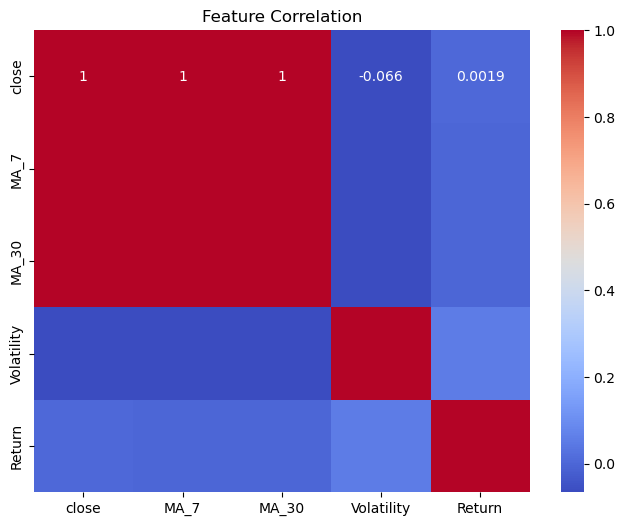

In [20]:
#Correlation heatmap
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(df[['close','MA_7','MA_30','Volatility','Return']].corr(), 
            annot=True, cmap='coolwarm')

plt.title("Feature Correlation")
plt.show()

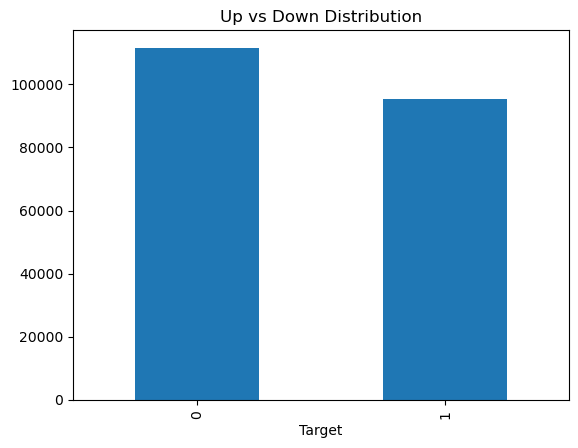

In [21]:
#Target distribution 
df['Target'].value_counts().plot(kind='bar')
plt.title("Up vs Down Distribution")
plt.show()

In [22]:
#Train test split - Time series analysis 
train_size = int(len(df) * 0.8)

train = df[:train_size]
test = df[train_size:]

In [23]:
#Selecting features 
features = ['MA_7', 'MA_30', 'Volatility', 'Return']

X_train = train[features]
y_train = train['Target']

X_test = test[features]
y_test = test['Target']

In [24]:
#Logistic regression 
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [25]:
#Predictions 
y_pred = model.predict(X_test)

In [26]:
#Evaluation 
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.52      1.00      0.68     21334
           1       0.00      0.00      0.00     20019

    accuracy                           0.52     41353
   macro avg       0.26      0.50      0.34     41353
weighted avg       0.27      0.52      0.35     41353



D:\anaconda setup\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
D:\anaconda setup\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
D:\anaconda setup\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [27]:
#Training random forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [28]:
#Predictions
rf_pred = rf_model.predict(X_test)

In [29]:
#Evaluation 
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.52      0.79      0.63     21334
           1       0.51      0.23      0.32     20019

    accuracy                           0.52     41353
   macro avg       0.52      0.51      0.47     41353
weighted avg       0.52      0.52      0.48     41353



<Axes: title={'center': 'Feature Importance'}>

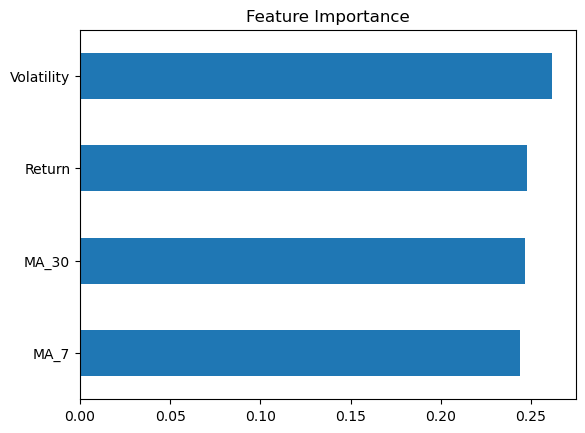

In [30]:
#Feature Importance 
import pandas as pd

importance = pd.Series(rf_model.feature_importances_, index=features)
importance.sort_values().plot(kind='barh', title="Feature Importance")